# Exercise 03 Guide: Molecular dynamics with OpenMM

## Aim of the exercise

We will learn to:

- prepare a real PDB entry for simulation with **PDBFixer**
- give a **ligand** parameters the protein force field does not have
- set up and run a solvated simulation of the **complex** with **OpenMM**, step by step
- analyse the resulting trajectory with **MDAnalysis** (RMSD, radius of gyration, RMSF)
- read what a simulation does and does not tell you

Everything is worked on **one complex, 2JAC** (yeast glutaredoxin-1 with its cosubstrate
glutathione), from raw download to per-residue flexibility, so you see one complete study
rather than fragments of several.

Based on the official tutorials of
[OpenMM](https://github.com/openmm/openmm_workshop_july2023) and
[MDAnalysis](https://userguide.mdanalysis.org/stable/examples/quickstart.html).

**Exercise 03 is two notebooks:**

| Notebook | What it is |
|---|---|
| **`ex03_guide.ipynb`** (this one) | The full worked simulation of 2JAC. Every cell is filled in and explained. Nothing here is graded. |
| **`ex03_workbook.ipynb`** | The graded notebook. Open it once you have finished here. |

**No GPU required.** Measured on a plain CPU: minimisation ~30 s, and ~35 s per 10 ps of
MD for this ~20,000-atom solvated system. The "kernel will be restarted" note below is
just the pip-install session restart, nothing to do with GPUs.


### Time budget, and what this notebook does not cover

**About 45 minutes** to read and run. Roughly 10 of those are the machine working rather
than you: about a minute to build the parametrisation environment, a few seconds for the
ligand itself, and the rest simulation.

**What you will not learn here:**

- **How to choose a force field.** We use Amber14 for the protein and OpenFF for the
  ligand because they are sane defaults, not because they are the only answer. Comparing
  force fields is a research project, not an exercise.
- **How to run a simulation long enough to mean something.** Tens of picoseconds is enough
  to show the machinery working and nothing like enough for a claim about biology. Real
  studies run microseconds.
- **Free energies.** Binding affinities need methods (FEP, umbrella sampling) that are out
  of scope for this block.
- **How the neural network that assigned the ligand's charges was trained.** We use it and
  check that its output behaves; opening it up belongs elsewhere.


<img src="openmm_logo.png" width="50"/>

# OpenMM

OpenMM is a versatile and high-performance toolkit designed for molecular simulation. It stands out due to its unique blend of features, which include extreme flexibility, openness, and exceptional performance, particularly on modern GPUs.

Summary of Contents:
1. **Setup Environment**: Instructions on preparing the necessary computational environment.
2. **Download Protein File**: Steps to obtain the required protein structure file.
3. **Load a PDB File into OpenMM**: Tutorial on how to import and use a PDB file within OpenMM.
4. **Choose the Force-Field**: Guidance on selecting appropriate force-fields for the simulation.
5. **Solvate the Protein with Water and Ions**: Process of adding water and ions to the protein environment.
6. **Setup System and Integrator**: Instructions on initializing the simulation system and integrator.
7. **Run Local Minimization**: Steps for performing local energy minimization of the system.
8. **Setup Reporting**: How to configure reporting tools for monitoring simulation progress.
9. **Run NVT Equilibration**: Conducting NVT (constant Number, Volume, Temperature) equilibration simulations.
10. **Run NPT Production Molecular Dynamics**: Executing NPT (constant Number, Pressure, Temperature) production simulations.
11. **Basic Analysis**: Introduction to fundamental analysis techniques for simulation data.
12. **How to Use Checkpoints**: Instructions on setting up and utilizing checkpoints for long-term simulations.
13. **Visualization**: Tips and tools for visualizing the simulation results.



## Setup

**A GPU is optional here, not required.** Measured on a plain Colab CPU runtime, the whole
2JAC workflow below takes roughly: minimisation ~30 s, NVT 10 ps ~33 s, NPT 10 ps ~36 s.
That is a couple of minutes for the complete simulation, which is well within a normal
session.

OpenMM *is* much faster on a GPU, and if you extend the run to hundreds of picoseconds
you will want one (Runtime → Change runtime type → GPU). For the guide as written, CPU is
the sensible default: Colab's GPU allocation is limited, and this exercise does not need
to spend it.

The note below about the kernel restarting is just the pip install; it has nothing to do
with GPUs.


In [20]:
if "google.colab" in str(get_ipython()):
    print("Running on colab")
    print("Installing required packages...")
    !pip install -q openmm==8.2.0 mdanalysis==2.10.0 py3dmol==2.4.0
    %pip install -q pdbfixer==1.12.0
    print("Installation complete!")
else:
    print("Not running on colab.")
    print("Make sure you have all required packages installed in your environment!")


Not running on colab.
Make sure you have all required packages installed in your environment!


**Note:** During this step on Colab the kernel will be restarted. This will produce the error message:
"Your session crashed for an unknown reason. " This is normal and you can safely ignore it.

**Note:** Installing the packages will take several minutes!

In [21]:
# check the installation
!python -m openmm.testInstallation


OpenMM Version: 8.2
Git Revision: 53770948682c40bd460b39830d4e0f0fd3a4b868

There are 2 Platforms available:

1 Reference - Successfully computed forces
2 CPU - Successfully computed forces

Median difference in forces between platforms:

Reference vs. CPU: 6.30524e-06

All differences are within tolerance.


In [22]:
import os
import subprocess
import sys
import urllib.request
from pathlib import Path
from sys import stdout

import matplotlib.pyplot as plt
import pandas as pd
import py3Dmol
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align

from pdbfixer import PDBFixer
from openmm.app import (
    CheckpointReporter,
    DCDReporter,
    ForceField,
    HBonds,
    Modeller,
    PDBFile,
    PME,
    Simulation,
    StateDataReporter,
)
from openmm import LangevinMiddleIntegrator, MonteCarloBarostat, XmlSerializer
from openmm.unit import (
    Quantity,
    amu,
    bar,
    kelvin,
    nanometer,
    picosecond,
    picoseconds,
    seconds,
)

print("Libraries loaded")


Libraries loaded


### A second environment, for the ligand's parameters

`amber14-all.xml` covers the 20 standard amino acids and water. It has **nothing** for an
arbitrary small molecule, so a ligand needs parameters of its own, and the toolchain that
produces them cannot be installed with `pip`: the OpenFF toolkit's only release on PyPI is
withdrawn, and GAFF's AmberTools is not published there at all.

conda-forge has all of it. So we fetch **micromamba**, one binary with no installer and no
kernel restart, and give the parametrisation its own small environment. One cell below
runs in that environment as a separate process, writes a parameter file, and hands it
back. Nothing else in this notebook changes.


In [23]:
# The ligand's parameters are built in their own environment, not in this kernel.
PARAM_ENV = Path("/opt/openff-env")

if "google.colab" in str(get_ipython()):
    if not (PARAM_ENV / "bin" / "python").exists():
        print("Installing micromamba + the OpenFF stack (about a minute, once per session)...")
        !curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xj -C /usr/local bin/micromamba
        !micromamba create -y -q -p {PARAM_ENV} -c conda-forge python=3.13 openff-toolkit openmmforcefields rdkit openmm
    PARAM_PYTHON = str(PARAM_ENV / "bin" / "python")
else:
    print("Not running on colab.")
    print("Use the course conda environment, which already includes the OpenFF stack.")
    PARAM_PYTHON = sys.executable

# Fail here, loudly, rather than three cells later.
_check = subprocess.run(
    [PARAM_PYTHON, "-c", "import openff.toolkit as t; print(t.__version__)"],
    capture_output=True, text=True)
if _check.returncode == 0:
    print(f"Parametrisation interpreter ready: {PARAM_PYTHON} "
          f"(openff-toolkit {_check.stdout.strip()})")
else:
    print("The OpenFF stack is NOT available; the ligand cells below will fail:")
    print(_check.stderr[-500:])


Not running on colab.
Use the course conda environment, which already includes the OpenFF stack.
The OpenFF stack is NOT available; the ligand cells below will fail:
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    import openff.toolkit as t; print(t.__version__)
    ^^^^^^^^^^^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'openff'



## Protein to study: 2JAC, yeast glutaredoxin-1

We simulate **2JAC**, the C30S mutant of yeast glutaredoxin-1: a real redox enzyme, and
the same protein you will analyse at the end of this notebook.

Two things make it a good teaching system. It is small (110 residues), so a full
solvated simulation finishes in minutes. And it is a **real, unmodified PDB entry**,
which means it is *not* ready to simulate as downloaded.

That last point is the lesson. A PDB file straight from the database routinely has
missing atoms, missing residues, no hydrogens, and heteroatoms the force field has never
heard of. Feeding one directly to OpenMM produces an error, not a simulation. The tool
for this is [PDBFixer](https://github.com/openmm/pdbfixer), and using it is the first
real step of any MD study, see also the
[OpenMM FAQs](https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions).


![2JAC](./2JAC.png)

**Figure.** Yeast glutaredoxin-1 (2JAC), coloured N-terminus (blue) to C-terminus (red).
The **yellow spheres** mark residue 30, the catalytic cysteine, mutated to serine (C30S)
in this construct to make it crystallisable and catalytically dead. The **green sticks**
are the bound cosubstrate **glutathione (GSH)**, sitting in the active site right beside
it. That is the molecule we are about to parametrise, and you can see how close to the
catalytic position it sits.

Note the fold: a central β-sheet flanked by α-helices, the **thioredoxin fold**, one of
the most widespread architectures in biology. Keep the shape in mind; you will be asked at
the end which parts of it moved.


### The cosubstrate stays

2JAC's crystal contains its genuine cosubstrate, glutathione, and we keep it. Simulating
the protein without its ligand would be a different experiment: an enzyme holding a
substrate is not the same physical system as an empty one, and the question this exercise
ends on, which parts of the fold move, has a different answer in each case.

Keeping it costs two steps the protein did not need:

- The crystal gives coordinates but **no bond orders**. A PDB file does not record which
  bonds are double, so the chemistry has to be recovered from the **chemical component
  dictionary**, the registry that named the ligand in the first place.
- Every atom needs a **partial charge**, which has classically meant a quantum calculation
  per molecule. We use a **graph neural network** trained to reproduce that calculation
  instead. It runs in under a second, and it is a fair example of a learned model standing
  in for a physical one somewhere nobody has to take it on faith: the result is a number
  you can inspect, and the simulation either stays stable or it does not.


### The preparation helpers

Four functions, defined once here and called everywhere below. These are the ones you will
need again on your own protein.

| Helper | Gives you |
|---|---|
| `fetch_pdb(pdb_id)` | the raw entry, downloaded once, as a local path |
| `prepare_structure(pdb_path, out_path)` | a simulatable protein, and a report of what had to be fixed |
| `ligand_from_crystal(pdb_path, code)` | one copy of the ligand, in one conformation, as its own PDB file |
| `parametrise_ligand(ligand_pdb, code)` | an OpenMM parameter file for that ligand |


In [24]:
def fetch_pdb(pdb_id: str, path: str | None = None) -> str:
    """Download one PDB entry next to the notebook, once. Returns the local path.

    Fetched with Python rather than wget, so this works identically on Colab, in a local
    conda environment, and in a container: the download is not a Colab-only step.
    MDAnalysis reads structures but does not retrieve them, so this stays plain urllib.
    """
    path = path or f"{pdb_id}.pdb"
    if not os.path.exists(path):
        urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_id}.pdb", path)
        print(f"Downloaded {path} from RCSB")
    else:
        print(f"{path} already present")
    return path


def prepare_structure(pdb_path: str, out_path: str, keep_water: bool = False,
                      ph: float = 7.0) -> str:
    """Run PDBFixer over a raw PDB entry and write a protein OpenMM can build.

    Prints what was missing before fixing it: a fixer that silently added twelve residues
    has made a modelling decision on your behalf, and you are responsible for it either
    way. Heteroatoms are removed here; the ligand is handled separately, because it needs
    parameters this force field does not have. Modified amino acids, such as the
    selenomethionine many crystals carry, become the standard one first: left alone,
    `removeHeterogens` would cut them out of the chain. Residue numbers stay the ones the
    input file uses.
    """
    fixer = PDBFixer(filename=pdb_path)
    fixer.findMissingResidues()
    fixer.findNonstandardResidues()
    nonstandard = [f"{residue.name}{residue.id}" for residue, _ in fixer.nonstandardResidues]
    fixer.replaceNonstandardResidues()
    fixer.removeHeterogens(keepWater=keep_water)
    fixer.findMissingAtoms()

    print(f"Missing residues found: {len(fixer.missingResidues)}")
    print(f"Missing atoms found   : {len(fixer.missingAtoms)}")
    print(f"Nonstandard residues  : {nonstandard}")

    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(ph)
    with open(out_path, "w") as out:
        PDBFile.writeFile(fixer.topology, fixer.positions, out, keepIds=True)

    print(f"\nPrepared {out_path}: {fixer.topology.getNumAtoms()} atoms, "
          f"{fixer.topology.getNumResidues()} residues")
    return out_path


def ligand_from_crystal(pdb_path: str, code: str, out_path: str | None = None) -> str:
    """One copy of a named species, in one conformation, as its own PDB file.

    Both filters earn their place. A crystal often models the ligand more than once, so we
    take the first residue. And where an atom was modelled in two **alternate positions**,
    MDAnalysis returns both as one residue: parametrising those overlapping copies as
    though they were a single molecule is a silent way to get nonsense. Entries with no
    alternates leave the field blank, which is why the blank is kept alongside "A".
    """
    universe = mda.Universe(pdb_path)
    ligand = universe.select_atoms(f"resname {code}")
    if not len(ligand):
        raise ValueError(f"no {code} residues in {pdb_path}")

    ligand = ligand.residues[0].atoms
    ligand = ligand[[altloc in (" ", "", "A") for altloc in ligand.altLocs]]

    out_path = out_path or f"{code}.pdb"
    ligand.write(out_path)
    print(f"Wrote {out_path}: {len(ligand)} atoms of {code}")
    return out_path


def parametrise_ligand(ligand_pdb: str, code: str,
                       python: str | None = None) -> tuple[str, str]:
    """Parameters for one ligand, built in the OpenFF environment.

    Runs as a separate process because that toolchain cannot be imported from this
    kernel. Returns (parameter file, ligand with hydrogens), and both are ordinary files:
    ForceField reads the first exactly as it reads Amber's own.
    """
    out_xml, out_pdb = f"{code}.xml", f"{code}_h.pdb"

    # A notebook kernel exports settings that only make sense inside it. MPLBACKEND
    # names Jupyter's inline backend, which the other environment does not have, and
    # PYTHONPATH points at this kernel's packages. Inherited, either one breaks the
    # subprocess with an error that looks nothing like its cause.
    environment = {key: value for key, value in os.environ.items()
                   if key not in ("MPLBACKEND", "PYTHONPATH", "PYTHONHOME")}

    result = subprocess.run(
        [python or PARAM_PYTHON, "_parametrise_ligand.py",
         str(ligand_pdb), code, out_xml, out_pdb],
        capture_output=True, text=True, env=environment)
    print(result.stdout.strip())
    if result.returncode != 0:
        print(result.stderr[-1500:])
        raise RuntimeError(f"parametrising {code} failed")
    return out_xml, out_pdb


In [25]:
# 2JAC comes straight from the PDB, so it is not simulatable as downloaded.
pdb_path = fetch_pdb("2JAC")


2JAC.pdb already present


### Preparing the structure

Each `fixer` call inside `prepare_structure` addresses one specific defect. Read them as a
checklist you will repeat for your own protein:

| Call | What it fixes |
|---|---|
| `findMissingResidues()` | gaps in the chain the crystallographer could not resolve |
| `findNonstandardResidues()` | modified residues the force field will not recognise |
| `replaceNonstandardResidues()` | turns them into the standard amino acid (selenomethionine into methionine), so the next call does not cut them out of the chain |
| `removeHeterogens(keepWater=False)` | ligands, ions and crystallographic waters, here GSH |
| `findMissingAtoms()` / `addMissingAtoms()` | side-chain atoms absent from the density |
| `addMissingHydrogens(7.0)` | hydrogens, protonated for pH 7.0, which X-ray rarely sees |

**Print what changed and check it.** A fixer that silently added 12 residues has made a
modelling decision on your behalf, and you are responsible for it either way.

**The residue numbers stay the file's.** `keepIds=True` in `writeFile` keeps them. Without
it OpenMM numbers every chain from 1 again, and residue 30 of the crystal need not be
residue 30 of your simulation. If `renumber_to_uniprot` changed your protein in ex01, start
from its file, not from the PDB download: then the same number also finds the residue in
UniProt and in AlphaFold's model.


In [26]:
fixed_path = prepare_structure(pdb_path, "2JAC_fixed.pdb")


Missing residues found: 1


Missing atoms found   : 0
Nonstandard residues  : []

Prepared 2JAC_fixed.pdb: 1749 atoms, 110 residues


### Parameters for the ligand

Pulling the ligand out of the crystal is a **selection** problem, so we use
[MDAnalysis](https://www.mdanalysis.org/) for it. It is usually met as a trajectory
library, and it is the one this notebook uses on the trajectory further down, but it reads
a single structure just as well and its selection language is the same in both places.
There is a fuller tour of it below; two lines of it are enough here.

The next cell after that is written to disk and run in the OpenFF environment rather than
here. It does three things, and each is a step you would otherwise have to justify to a
reviewer:

1. **Recovers the chemistry.** The crystal has coordinates; the chemical component
   dictionary has the SMILES. Matching one onto the other restores the bond orders a PDB
   file cannot carry.
2. **Assigns partial charges** with a graph neural network trained on quantum results,
   rather than running the quantum calculation itself.
3. **Writes a residue template**, an ordinary OpenMM parameter file, which the next
   section loads alongside Amber's.

⚠️ **Read the charge on the molecule it prints.** The dictionary hands you the *neutral*
form, and at pH 7 glutathione carries a net negative charge. Simulating the neutral form
is a modelling decision, and it is yours to make rather than the pipeline's to make
silently.


In [27]:
%%writefile _parametrise_ligand.py
# Runs in the OpenFF environment, not in this notebook's kernel.
# Usage: python _parametrise_ligand.py <ligand.pdb> <CODE> <out.xml> <out.pdb>
import json
import sys
import urllib.request

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from openff.toolkit import Molecule
from openmm.app import PDBFile, Topology
from openmm.app.element import Element
from openmmforcefields.generators import SMIRNOFFTemplateGenerator

RDLogger.DisableLog("rdApp.*")
ligand_pdb, code, out_xml, out_pdb = sys.argv[1:5]

# 1. the chemistry a PDB file does not carry
record = json.load(urllib.request.urlopen(
    f"https://data.rcsb.org/rest/v1/core/chemcomp/{code}", timeout=30))
smiles = next(d["descriptor"] for d in record["pdbx_chem_comp_descriptor"]
              if d.get("type") == "SMILES_CANONICAL"
              and d.get("program") == "OpenEye OEToolkits")

# removeHs is load-bearing: some entries deposit explicit hydrogens, and the dictionary
# template is heavy-atom only, so matching with hydrogens present fails on valence.
crystal = Chem.MolFromPDBBlock(open(ligand_pdb).read(), removeHs=True)
mol = Chem.AddHs(AllChem.AssignBondOrdersFromTemplate(
    Chem.MolFromSmiles(smiles), crystal), addCoords=True)

# 2. partial charges, from a graph neural network rather than from quantum chemistry
ligand = Molecule.from_rdkit(mol, allow_undefined_stereo=True)
ligand.name = code
ligand.assign_partial_charges("openff-gnn-am1bcc-1.0.0.pt")

# 3. the residue template, as an ordinary OpenMM parameter file
forcefield = sorted(f for f in SMIRNOFFTemplateGenerator.INSTALLED_FORCEFIELDS
                    if f.startswith("openff-2"))[-1]
generator = SMIRNOFFTemplateGenerator(molecules=ligand, forcefield=forcefield)
open(out_xml, "w").write(generator.generate_residue_template(ligand))

# The coordinates go out afterwards, and the topology is built by hand rather than
# converted. Converting splits the hydrogens into a chain of their own, and OpenMM then
# reads them back as a second residue holding nothing but hydrogens, which matches no
# template. One chain, one residue, every atom and every bond.
topology = Topology()
residue = topology.addResidue(code, topology.addChain())
counts, atoms = {}, []
for atom in ligand.atoms:
    element = Element.getByAtomicNumber(atom.atomic_number)
    counts[element.symbol] = counts.get(element.symbol, 0) + 1
    atoms.append(topology.addAtom(f"{element.symbol}{counts[element.symbol]}",
                                  element, residue))
for bond in ligand.bonds:
    topology.addBond(atoms[bond.atom1_index], atoms[bond.atom2_index])

with open(out_pdb, "w") as handle:
    PDBFile.writeFile(topology, ligand.conformers[0].to_openmm(), handle)

print(f"{code}: {mol.GetNumAtoms()} atoms with hydrogens, formal charge "
      f"{Chem.GetFormalCharge(mol):+d}, {forcefield} -> {out_xml}")


Overwriting _parametrise_ligand.py


In [28]:
LIGAND = "GSH"

# What else is in this crystal? MDAnalysis reads a structure file as happily as it reads a
# trajectory, and the selection language is the same one we use on the trajectory later.
crystal = mda.Universe(pdb_path)
other = crystal.select_atoms("not protein and not resname HOH")
print(f"Non-protein, non-water species in {pdb_path}: "
      f"{sorted(set(other.residues.resnames))}")

ligand_crystal = ligand_from_crystal(pdb_path, LIGAND)
ligand_xml, ligand_pdb = parametrise_ligand(ligand_crystal, LIGAND)


Non-protein, non-water species in 2JAC.pdb: ['GSH']
Wrote GSH.pdb: 20 atoms of GSH

Traceback (most recent call last):
  File "/home/yerko/Development/structural-bioinformatics-lectures/exercises/ex03/_parametrise_ligand.py", line 9, in <module>
    from openff.toolkit import Molecule
ModuleNotFoundError: No module named 'openff'



RuntimeError: parametrising GSH failed

## Load the structures into OpenMM
<a id="load"></a>

Two files now, not one: the prepared protein, and the ligand as the parametrisation wrote
it, with hydrogens and with atom names that match its parameter file. Both are read by the
same [PDBFile](http://docs.openmm.org/latest/api-python/generated/openmm.app.pdbfile.PDBFile.html#openmm.app.pdbfile.PDBFile) class.


In [ ]:
# Load the PREPARED protein -- never the raw download -- and the parametrised ligand.
pdb = PDBFile(fixed_path)
ligand = PDBFile(ligand_pdb)
print(f"Protein: {pdb.topology.getNumAtoms()} atoms, "
      f"{pdb.topology.getNumResidues()} residues")
print(f"Ligand : {ligand.topology.getNumAtoms()} atoms")


`PDBFile('file_name.pdb')` loads the PDB file from disk and puts the information into a `PDBFile` object which we have assign to the variable `pdb`. The object contains the molecular topology (atom names, residue types, bonds etc) and the atomic positions. These can be accessed as `pdb.topology` and `pdb.positions`. Take a look at the [API documentation](http://docs.openmm.org/latest/api-python/generated/openmm.app.pdbfile.PDBFile.html#openmm.app.pdbfile.PDBFile). All OpenMM classes have documentation available on the Python API reference: http://docs.openmm.org/latest/api-python/.

## Define the force field
<a id="ff"></a>

We need to define the forcefield we want to use. We will use the Amber14 forcefield and the TIP3P-FB water model. You can find out about all the forcefields available by default in OpenMM in the [documentation](http://docs.openmm.org/latest/userguide/application/02_running_sims.html?highlight=forcefield#force-fields).

In [ ]:
# Amber for the protein and the water, the generated template for the ligand. A force
# field is just a list of parameter files, and the ligand's is one more entry.
forcefield = ForceField("amber14-all.xml", "amber14/tip3pfb.xml", ligand_xml)


Force fields are defined by XML files. The line above loads three: `amber14-all.xml` for
the protein, `amber14/tip3pfb.xml` for the water model, and the one we generated for the
ligand. You can look at the Amber files in the
[OpenMM GitHub repository](https://github.com/openmm/openmm/tree/master/wrappers/python/openmm/app/data),
and at the generated one by opening it in this notebook's file browser. It has the same
shape: atom types, charges, bonds, angles and torsions.

The reason the ligand needed its own file is visible there. Amber's files name residues it
knows (`ALA`, `HOH`); nothing in them describes glutathione, so without the third file
`createSystem` would stop with "No template found for residue".


## Solvate
<a id="solvate"></a>

We can use the [`Modeller`](http://docs.openmm.org/latest/userguide/application/03_model_building_editing.html#model-building-and-editing) class to solvate the protein in a waterbox. 

In [ ]:
# Modeller assembles the system: protein first, then the ligand, then the water.
modeller = Modeller(pdb.topology, pdb.positions)
modeller.add(ligand.topology, ligand.positions)
print(f"Complex: {modeller.topology.getNumAtoms()} atoms "
      f"(protein + {LIGAND}), before solvation")

# Solvate the complex in a box of water
modeller.addSolvent(forcefield, padding=1.0 * nanometer)
print(f"Solvated: {modeller.topology.getNumAtoms()} atoms")


This command creates a box that has edges at least 1nm away from the solute and fills it with water molecules. Additionally, it adds in the required number of CL- and Na+ ions to make the system charge neutral. Optionally, you can specify the ion concentration as an argument to [`addSolvent`](http://docs.openmm.org/latest/api-python/generated/openmm.app.modeller.Modeller.html#openmm.app.modeller.Modeller.addSolvent). 

Note that the `nanometer` variable is a unit definition that was imported from `openmm.unit`. This is an example of the powerful units tracking and automatic conversion facility built into the OpenMM Python API that makes specifying unit-bearing quantities convenient and less error-prone. We could have equivalently specified `10*angstrom` instead of `1*nanometer` and achieved the same result. You can read more about the units library [here](http://docs.openmm.org/latest/userguide/library/05_languages_not_cpp.html#units-and-dimensional-analysis).

## Setup system and Integrator
<a id='system'></a>

We now need to combine our molecular topology and the forcefield to create a complete description of the system. This is done using the [`ForceField`](http://docs.openmm.org/latest/api-python/generated/openmm.app.forcefield.ForceField.html#forcefield) object's [`createSystem()`](http://docs.openmm.org/latest/api-python/generated/openmm.app.forcefield.ForceField.html#openmm.app.forcefield.ForceField.createSystem) method. We then create the integrator, and combine the integrator and system to create the Simulation object. Finally we set the initial atomic positions.

**Three settings there decide whether this runs at all**, and they are not independent:
the **timestep** (4 fs, on the integrator), the **constraints** on bonds to hydrogen, and
the **hydrogen mass**. A timestep has to be several times shorter than the fastest motion
in the system, and the fastest motions all involve hydrogen. Constraints remove the bond
stretching; repartitioning mass onto the hydrogens slows what is left. Change one of the
three and you have to reconsider the others.


In [ ]:
# Create a system. Here we define some forcefield settings such as the nonbonded method.
#
# `hydrogenMass` is what makes the 4 fs timestep below safe. Constraining bonds to
# hydrogen removes their stretching, but hydrogens still move fastest of anything in the
# system, and 4 fs is too long for them. Moving mass from each heavy atom onto the
# hydrogens attached to it slows those motions down without changing the total mass or
# the equilibrium thermodynamics. Without it this system runs for a few thousand steps
# and then dies with "Particle coordinate is NaN", sometimes.
system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=PME,
    nonbondedCutoff=1.0 * nanometer,
    constraints=HBonds,
    hydrogenMass=1.5 * amu,
)

# Define the integrator. The Langevin integrator is also a thermostat
integrator = LangevinMiddleIntegrator(300 * kelvin, 1 / picosecond, 0.004 * picoseconds)

# Create the Simulation
simulation = Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)


The [System](http://docs.openmm.org/latest/api-python/generated/openmm.openmm.System.html#system) is an object than contains the complete mathematical description of the system we want to simulate. It contains four key bits of information:
 - The set of particles in the simulation
 - The forces acting on them
 - Details of any constraints
 - The dimensions of the periodic box

The `integrator` advances the equations of motion. There are a variety of [integrators available in OpenMM](http://docs.openmm.org/latest/api-python/library.html#integrators). We are using the [LangevinMiddleIntegrator](http://docs.openmm.org/latest/api-python/generated/openmm.openmm.LangevinMiddleIntegrator.html#openmm.openmm.LangevinMiddleIntegrator) which performs Langevin dynamics.

The [`Simulation`](http://docs.openmm.org/latest/api-python/generated/openmm.app.simulation.Simulation.html#openmm.app.simulation.Simulation) object manages all the process involved in running a simulation, such as advancing time and writing output. 


## Local energy minimization
<a id="minim"></a>

It is a good idea to run local energy minimization at the start of a simulation because the coordinates in starting configuration file might produce very large forces. 

Due to how the minimizer is implemented it will not print out information during the run. You will need to be patient and wait for it to complete. This minimization step should take ~1 minute on CPU and a few seconds on GPU.

In [ ]:
print("Minimizing energy")
simulation.minimizeEnergy()

Minimizing energy


## Setup reporting
<a id="reporting"></a>

To get output from a simulation you need to add "reporters". We use [`DCDReporter`](http://docs.openmm.org/latest/api-python/generated/openmm.app.dcdreporter.DCDReporter.html) to write the coordinates every 1000 timesteps to 'traj.dcd' and we use [`StateDataReporter`](http://docs.openmm.org/development/api-python/generated/openmm.app.statedatareporter.StateDataReporter.html) to print the timestep, potential energy, temperature, and volume to the screen; and the same to a file called 'md_log.txt'. The Simulation object contains a list of reporters in `simulation.reporters` and we use the append method to add the reporters to it.

### The reporting helper

| Helper | Gives you |
|---|---|
| `attach_reporters(simulation, append=..., checkpoint=...)` | trajectory, screen and log-file output on one Simulation |

Reporters belong to a `Simulation` object, not to the run. Every time you build a new one,
including when you resume from a checkpoint further down, you attach them again. That is
the whole reason this is a function.


In [ ]:
def attach_reporters(simulation: Simulation, dcd: str = "traj.dcd",
                     log: str = "md_log.txt", every: int = 1000, log_every: int = 100,
                     checkpoint: str | None = None,
                     append: bool = False) -> Simulation:
    """Trajectory, screen and log-file reporting for one Simulation object.

    `append=True` extends an existing trajectory and log instead of overwriting them,
    which is what a resumed run needs. Pass `checkpoint` to also write restart files.
    """
    simulation.reporters.append(DCDReporter(dcd, every, append=append))
    simulation.reporters.append(StateDataReporter(
        stdout, every, step=True, potentialEnergy=True, temperature=True, volume=True))
    simulation.reporters.append(StateDataReporter(
        log, log_every, step=True, potentialEnergy=True, temperature=True, volume=True,
        append=append))
    if checkpoint:
        simulation.reporters.append(CheckpointReporter(checkpoint, every))
    return simulation


In [ ]:
attach_reporters(simulation)


## NVT equilibration
<a id=nvt></a>

We are using a Langevin integrator which means we are simulating in the NVT ensemble. To equilibrate the temperature we just need to run the simulation for a number of timesteps.

In [ ]:
print("Running NVT")
simulation.step(1000)

Running NVT


#"Step","Potential Energy (kJ/mole)","Temperature (K)","Box Volume (nm^3)"


1000,-321585.4877557783,292.11721024962634,213.7130788709624


## NPT production MD
<a id=npt></a>

To run our simulation in the NPT ensemble we need to add in a barostat to control the pressure. We can use [`MonteCarloBarostat`](http://docs.openmm.org/latest/api-python/generated/openmm.openmm.MonteCarloBarostat.html#openmm.openmm.MonteCarloBarostat). The parameters are the pressure (1 bar) and the temperature (300 K). The barostat assumes the simulation is being run at constant temperature, but it does not itself do anything to regulate the temperature. It is therefore critical that you always use it along with a Langevin integrator or Andersen thermostat, and that you specify the same temperature for both the barostat and the integrator or thermostat. Otherwise, you will get incorrect results.

In [ ]:
system.addForce(MonteCarloBarostat(1 * bar, 300 * kelvin))

# It is important to call the reinitialize method on the simulation
# otherwise the modifications will not be applied.
simulation.context.reinitialize(preserveState=True)

We then run the simulation for 10000 steps.

In [ ]:
print("Running NPT")
simulation.step(10000)

Running NPT


2000,-318848.39218536386,299.9481628675177,205.39194809484042


3000,-320626.3868143156,298.7032252996111,202.86035172727952


4000,-322028.4011578307,294.8341083042355,201.77572607795315


5000,-321230.34470906854,300.2553276297536,200.9080101531201


...

7000,-319667.3367049609,301.2756551726291,200.62447804063635


8000,-320348.34811607306,302.9274805629058,200.98239696517373


9000,-321673.6937404714,300.1245504010138,201.0607328417927


10000,-321024.5117789719,298.86158604911054,202.0658537995148


11000,-320659.0885235796,300.69751905073235,201.8491660968694


## Analysis
<a id=analysis></a>

We can now do some basic analysis using Python. We will plot the time evolution of the potential energy, temperature, and box volume. Remember that OpenMM itself is primarily an MD engine, for in-depth analysis of your simulations you can use other python packages such as [MDtraj](https://www.mdtraj.org/), or [MDAnalysis](https://www.mdanalysis.org/).


### The log helper

| Helper | Gives you |
|---|---|
| `plot_log(path)` | the reporter's log file as three stacked panels, and the table behind them |

You will call this again after the longer run further down, which is exactly why it is
not eight lines of plotting repeated twice.


In [ ]:
def plot_log(path: str = "md_log.txt") -> pd.DataFrame:
    """The StateDataReporter log as three stacked panels. Returns the DataFrame.

    pandas plots through matplotlib, and `subplots=True` turns one call into a panel per
    column, so the whole figure is one statement.
    """
    log = (pd.read_csv(path, delimiter=",", header=0)
           .rename(columns={'#"Step"': "Step"})
           .set_index("Step"))
    columns = ["Potential Energy (kJ/mole)", "Temperature (K)", "Box Volume (nm^3)"]
    axes = log[columns].plot(subplots=True, figsize=(11, 7), legend=False, sharex=True)
    for ax, label in zip(axes, ["Potential energy\n(kJ/mol)", "Temperature (K)",
                                "Box volume (nm^3)"]):
        ax.set_ylabel(label)
    axes[0].set_title("Simulation log")
    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    plt.show()
    return log


In [ ]:
log = plot_log()
log.describe().round(2)


## Checkpointing
<a id=checkpoints></a>

When you run long simulations it is useful to be able to save checkpoints. This means you can restart them in the case of a crash. Or it means you can resume them if you need to fit within the time constraints of a HPC job scheduler.

To run a resume a simulation we need to have three files saved to disk that we can load in:
1. The topology - this will be a PDB file of our solvated system.
2. A serialized `System` -  this is an xml file that contains the forcefield settings.
3. A checkpoint file - this is a binary file that contains the positions, velocities, box vectors, and other internal data such as the states of random number generators.

The first two only need to be saved once because they are constant throughout the simulation. The checkpoint file needs to be saved frequently. You can then resume a simulation from the timestep when the checkpoint file was last saved.


### Setup the checkpoint

We will create the topology file using `PDBFile` to write a PDB file of the system. We will use `XmlSerializer` of save the serialized system to an xml file. And we will use `CheckpointReporter` to regularly create checkpoint files.

In [ ]:
# Save the toplogy as a PDB file.
with open("topology.pdb", "w") as output:
    PDBFile.writeFile(
        simulation.topology,
        simulation.context.getState(getPositions=True).getPositions(),
        output,
        keepIds=True,  # the residue numbers of the prepared file
    )

# save a serialized version of the system. This stores the forcefield parameters.
with open("system.xml", "w") as output:
    output.write(XmlSerializer.serialize(system))

# Setup a checkpoint reporter. This stores the positions, velocities, and box vectors. It will save
# a checkpoint every 1000 timesteps.
simulation.reporters.append(CheckpointReporter("checkpoint.chk", 1000))


### Visualize the initial structure

`py3Dmol` draws the system directly in the notebook. The same view is worth looking at
again at the end, on the trajectory's last frame, so it is a function rather than a block
of styling calls.

| Helper | Gives you |
|---|---|
| `show_system(pdb_path)` | protein as cartoon, water and ions as spheres |


In [ ]:
def show_system(pdb_path: str, ligand: str | None = None, width: int = 800,
                height: int = 500) -> py3Dmol.view:
    """The whole simulated box: protein as cartoon, water and ions as spheres.

    `ligand` draws one heteroatom species as sticks, which is the only way to see it at
    all once it is surrounded by several thousand waters.
    """
    view = py3Dmol.view(width=width, height=height)
    view.addModel(Path(pdb_path).read_text(), "pdb")
    view.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})
    view.addStyle({"resn": "HOH"}, {"sphere": {"radius": 0.4}})
    view.addStyle({"resn": ["NA", "CL"]}, {"sphere": {"radius": 1, "color": "yellow"}})
    if ligand:
        view.addStyle({"resn": ligand}, {"stick": {"colorscheme": "greenCarbon"}})
    view.zoomTo()
    return view


In [ ]:
print("Initial structure (full system: protein + ligand + water + ions):")
show_system("topology.pdb", ligand=LIGAND).show()


`CheckpointReporter` saves periodic checkpoints of a simulation. The checkpoints will overwrite one another - only the last checkpoint will be saved in the file. Loading a checkpoint will restore a simulation to a reasonably close, but usually not identical, state to when it was written. The checkpoint contains data that is highly specific to the System, Platform, and the hardware and software of the computer it was created on. If you try and load it on a computer with different hardware it is likely to fail. Checkpoints created with different versions of OpenMM are often incompatible. 

For a more portable way of saving the state of a simulation you can save the checkpoint as an xml state file. Read the [API docs](http://docs.openmm.org/development/api-python/generated/openmm.app.checkpointreporter.CheckpointReporter.html) for more information.

### Running for a set time limit

We can run for a set amount of wall-clock time using the [`runForClockTime`](http://docs.openmm.org/latest/api-python/generated/openmm.app.simulation.Simulation.html#openmm.app.simulation.Simulation.runForClockTime) method. By [wall-clock](https://en.wikipedia.org/wiki/Elapsed_real_time) time we mean the actual time a program runs for as measured by looking at a clock on a wall (or a watch, or a timer etc) as opposed to the simulated time.


In [ ]:
# run for 30 seconds
simulation.runForClockTime(30.0 * seconds)

12000,-320354.1786625207,301.3376321348948,201.8101869183157


13000,-321625.8077449101,299.09957276197326,200.93316055581892


14000,-321694.53500472975,299.3248041931107,201.58750234413628


### Resume from a checkpoint

We now have the three files we need: `topology.pdb`, `system.xml` and `checkpoint.chk`.
Resuming means rebuilding the `Simulation` from them, then attaching the reporters again
with `append=True` so the trajectory and the log are extended rather than overwritten.

| Helper | Gives you |
|---|---|
| `simulation_from_checkpoint(...)` | a Simulation restored to the last saved state |


In [ ]:
def simulation_from_checkpoint(topology: str = "topology.pdb",
                               system_xml: str = "system.xml",
                               checkpoint: str = "checkpoint.chk",
                               temperature: Quantity = 300 * kelvin,
                               friction: Quantity = 1 / picosecond,
                               timestep: Quantity = 0.004 * picoseconds) -> Simulation:
    """Rebuild a Simulation from the three saved files and restore its state.

    The topology and the serialised system come back from disk; the integrator has to be
    created again, because it is not part of either file. The checkpoint then restores
    positions, velocities and box vectors.
    """
    pdb = PDBFile(topology)
    with open(system_xml) as handle:
        system = XmlSerializer.deserialize(handle.read())
    integrator = LangevinMiddleIntegrator(temperature, friction, timestep)
    simulation = Simulation(pdb.topology, system, integrator)
    simulation.loadCheckpoint(checkpoint)
    return simulation


In [ ]:
simulation = simulation_from_checkpoint()
attach_reporters(simulation, checkpoint="checkpoint.chk", append=True)

# run for 30 seconds of wall-clock time
simulation.runForClockTime(30.0 * seconds)


### Resume multiple times

We can practice resuming several times over. This is something you might have to do to fit
a long simulation within the limits of an HPC job scheduler: each resume picks up from the
last checkpoint and appends to the same trajectory.


In [ ]:
for i in range(3):
    print("Resuming from checkpoint iteration = ", i)
    simulation = simulation_from_checkpoint()
    attach_reporters(simulation, checkpoint="checkpoint.chk", append=True)
    simulation.runForClockTime(30.0 * seconds)


### Analysis

we can redo the analysis on the longer trajectory.

In [ ]:
log = plot_log()


# MDAnalysis

You have already used [MDAnalysis](https://www.mdanalysis.org/) once, to pull the ligand
out of the crystal. Here is the library properly.

It reads and writes the common MD formats, gives you atomic coordinates as NumPy arrays,
and carries a powerful atom-selection language. The important idea is that a **structure**
and a **trajectory** are the same kind of object to it: one has a single frame, the other
has thousands, and the selections you write do not change between them.


MDAnalysis is a Python package for accessing and analyzing molecular dynamics trajectory data. Its core data structures include:

- **Atom**: Represents a particle, even if it's a coarse-grained bead.
- **AtomGroup**: A crucial class where atoms are grouped. Most data can be accessed through AtomGroups.
- **Universe**: Combines all particles in an AtomGroup with a trajectory, providing access to the entire molecular system.

Working with MDAnalysis typically starts with loading data into a `Universe`.

In [ ]:
# loading a trajectory
u = mda.Universe("topology.pdb", "traj.dcd")
u

/home/yerko/Development/structural-bioinformatics-lectures/exercises/.venv/lib/python3.13/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


<Universe with 20334 atoms>

### Visualize the last frame

We can extract the last frame from the trajectory and hand it to the same `show_system`
helper we used on the starting structure. Comparing the two views is the cheapest
sanity check there is: if the protein has left the box or come apart, you will see it.


In [ ]:
# Go to the last frame of the trajectory and write it out
u.trajectory[-1]
with mda.Writer("last_frame.pdb", u.atoms.n_atoms) as writer:
    writer.write(u.atoms)

print("Last frame (full system: protein + ligand + water + ions):")
show_system("last_frame.pdb", ligand=LIGAND).show()


The trajectory of the simulation is saved in the `u.trajectory` attribute. It is an iterator that yields a `Timestep` object for each frame in the trajectory. The `Timestep` object contains the coordinates of all atoms in the simulation at a given time step. The `Timestep` object also contains the simulation box dimensions, the simulation time, and the simulation step.

In [ ]:
# Get the number of frames in the trajectory
len(u.trajectory)

26

Get the number of residues and atoms in the protein

In [ ]:
u.residues, u.atoms

(<ResidueGroup with 6309 residues>, <AtomGroup with 20334 atoms>)

MDAnalysis has powerful selection tools that allow you to select atoms based on their properties. For example:

In [ ]:
# Select the first 5 residues of the protein
print(u.select_atoms("resid 1:5").residues)
# Select the residues that are within 5 angstroms of the first residue
print(u.select_atoms("around 5 resid 1").residues)
# Selec the PHE residues
print(u.select_atoms("resname PHE").residues)

<ResidueGroup [<Residue MET, 1>, <Residue VAL, 2>, <Residue SER, 3>, <Residue GLN, 4>, <Residue GLU, 5>, <Residue HOH, 1>, <Residue HOH, 2>, <Residue HOH, 3>, <Residue HOH, 4>, <Residue HOH, 5>]>
<ResidueGroup [<Residue VAL, 2>, <Residue SER, 3>, <Residue GLN, 4>, ..., <Residue HOH, 6117>, <Residue HOH, 6129>, <Residue HOH, 6179>]>
<ResidueGroup [<Residue PHE, 20>, <Residue PHE, 38>]>


For the `Universe` object, water molecules are considered as residues. To select only the protein, you can use the `protein` keyword.

In [ ]:
# Select the protein
protein = u.select_atoms("protein")

In [ ]:
type(protein)

MDAnalysis.core.groups.AtomGroup

`AtomGroups` are the core data structure in MDAnalysis. You can get the positions of the atoms in an `AtomGroup` as a numpy array, as well as other properties such as the atom names, residue names, residue numbers, and residue IDs.

In [ ]:
protein.positions

array([[23.381891 , 47.966652 , 19.951542 ],
       [22.954823 , 48.693985 , 20.507143 ],
       [23.255402 , 47.014854 , 20.264894 ],
       ...,
       [ 7.9092326, 17.925459 , -8.486598 ],
       [ 8.705146 , 18.805283 , -8.09918  ],
       [ 8.2776985, 16.707853 , -8.4488735]], dtype=float32)

In [ ]:
print("Center of Mass:", protein.center_of_mass())
print("Center of Geometry:", protein.center_of_geometry())
print("Total Mass:", protein.total_mass())
print("Radius of Gyration:", protein.radius_of_gyration())

Center of Mass: [12.02084018 30.36097315  8.89392226]
Center of Geometry: [12.12331357 30.3270615   8.85503152]
Total Mass: 12358.109999999997
Radius of Gyration: 13.92064224830834


## Working with trajectories

The trajectory of a Universe contains the changing coordinate information. 
The standard way to assess the information of each frame in a trajectory is to iterate over it. When the timestep changes, the universe only contains information associated with that timestep.



In [ ]:
for ts in u.trajectory:
    time = u.trajectory.time
    rgyr = protein.radius_of_gyration()
    print(f"Frame: {ts.frame:3d}, Time: {time:4.0f} ps, Rgyr: {rgyr:.4f} A")

Frame:   0, Time:    4 ps, Rgyr: 14.1969 A
Frame:   1, Time:    8 ps, Rgyr: 13.9100 A
Frame:   2, Time:   12 ps, Rgyr: 14.0395 A
Frame:   3, Time:   16 ps, Rgyr: 13.9621 A
Frame:   4, Time:   20 ps, Rgyr: 13.9219 A
Frame:   5, Time:   24 ps, Rgyr: 13.9009 A
Frame:   6, Time:   28 ps, Rgyr: 14.0025 A
Frame:   7, Time:   32 ps, Rgyr: 13.9338 A
Frame:   8, Time:   36 ps, Rgyr: 13.8934 A
Frame:   9, Time:   40 ps, Rgyr: 13.9568 A
Frame:  10, Time:   44 ps, Rgyr: 13.8949 A
Frame:  11, Time:   48 ps, Rgyr: 13.9590 A
Frame:  12, Time:   52 ps, Rgyr: 13.8605 A
Frame:  13, Time:   56 ps, Rgyr: 13.9365 A
Frame:  14, Time:   60 ps, Rgyr: 13.9555 A
Frame:  15, Time:   64 ps, Rgyr: 13.9449 A
Frame:  16, Time:   68 ps, Rgyr: 13.9138 A
Frame:  17, Time:   72 ps, Rgyr: 13.9212 A
Frame:  18, Time:   76 ps, Rgyr: 13.8720 A
Frame:  19, Time:   80 ps, Rgyr: 13.9841 A
Frame:  20, Time:   84 ps, Rgyr: 13.9409 A
Frame:  21, Time:   88 ps, Rgyr: 13.8990 A
Frame:  22, Time:   92 ps, Rgyr: 13.9450 A
Frame:  23,

In order to collect the radius of gyration, we can iterate over the trajectory and store the information in a list.
This can then be converted into other data structures, such as a numpy array or a pandas DataFrame. It can be plotted (as below), or used for further analysis.

The helper below is exactly that loop with the values kept instead of printed.

| Helper | Gives you |
|---|---|
| `rgyr_over_time(u)` | radius of gyration per frame, indexed by simulation time |


In [ ]:
def rgyr_over_time(u: mda.Universe, selection: str = "protein") -> pd.DataFrame:
    """Radius of gyration per frame, indexed by simulation time in ps."""
    group = u.select_atoms(selection)
    times, values = [], []
    for _ in u.trajectory:
        times.append(u.trajectory.time)
        values.append(group.radius_of_gyration())
    rgyr = pd.DataFrame({"Radius of gyration (A)": values}, index=times)
    rgyr.index.name = "Time (ps)"
    return rgyr


In [ ]:
rgyr_df = rgyr_over_time(u)
rgyr_df


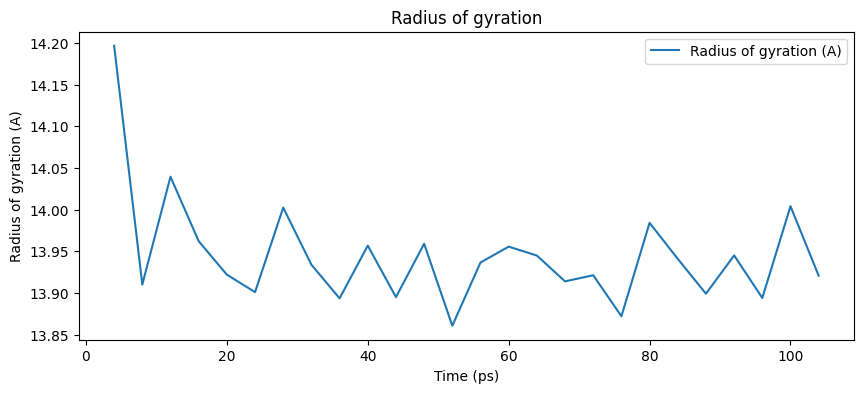

In [ ]:
# pandas -> matplotlib: `.plot()` returns an Axes we can label directly.
ax = rgyr_df.plot(figsize=(10, 4), title="Radius of gyration")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Radius of gyration (A)")
plt.show()

RMSD is a common metric for assessing the similarity of two structures.

In [ ]:
bb = u.select_atoms("backbone")

u.trajectory[0]  # first frame
first = bb.positions

u.trajectory[-1]  # last frame
last = bb.positions

rms.rmsd(first, last)

np.float64(2.1689731429395476)

In the trajectory analysis, we can calculate the RMSD of every frame against the first,
and then how much each individual residue fluctuates. Both are `MDAnalysis.analysis.rms`
calculations wrapped so they hand back a table you can plot.

| Helper | Gives you |
|---|---|
| `rmsd_over_time(u, select=..., groupselections=...)` | one column per selection, indexed by time |
| `rmsf_per_residue(u)` | per-residue fluctuation about the average structure |


In [ ]:
def rmsd_over_time(u: mda.Universe, select: str = "backbone",
                   groupselections: tuple[str, ...] = ("name CA", "protein")
                   ) -> pd.DataFrame:
    """RMSD of every frame against the first, one column per selection.

    MDAnalysis returns a plain array whose first two columns are the frame number and the
    time; those become the index here, because what you want to plot is RMSD against time.
    """
    u.trajectory[0]
    analysis = rms.RMSD(u, select=select, groupselections=list(groupselections)).run()
    rmsd = pd.DataFrame(analysis.results.rmsd[:, 2:],
                        columns=[select, *groupselections],
                        index=analysis.results.rmsd[:, 1])
    rmsd.index.name = "Time (ps)"
    return rmsd


def rmsf_per_residue(u: mda.Universe,
                     selection: str = "protein and name CA") -> pd.DataFrame:
    """Per-residue fluctuation about the trajectory's own average structure.

    Every frame is aligned to that average first. Without the alignment the numbers
    measure the protein tumbling around the box rather than its internal motion. The
    alignment is done in memory, so call this after any RMSD you want on raw coordinates.
    """
    average = align.AverageStructure(u, u, select=selection, ref_frame=0).run()
    align.AlignTraj(u, average.results.universe, select=selection, in_memory=True).run()
    atoms = u.select_atoms(selection)
    analysis = rms.RMSF(atoms).run()
    return pd.DataFrame({"resid": atoms.resids, "RMSF": analysis.results.rmsf})


In [ ]:
rmsd_df = rmsd_over_time(u)
rmsd_df.head()


One row per frame, one column per selection, and the simulation time as the index. The
three columns are the RMSD of the backbone, of the C-alpha atoms alone, and of the whole
protein including side chains.


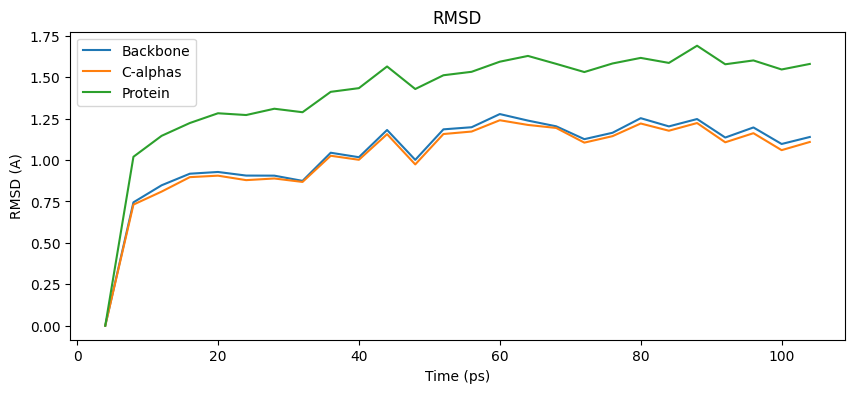

In [ ]:
# pandas -> matplotlib: `.plot()` returns an Axes we can label directly.
ax = rmsd_df.plot(figsize=(10, 4), title="RMSD")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("RMSD (A)")
plt.show()

**How you'd reason about this before running anything (a worked example of
predict-first):**

2JAC's cofactor, GSH, binds at the active site next to residue 30 (mutated to Ser here,
C30S, the crystallisation-friendly and catalytically dead version of the real catalytic
cysteine). Before running the analysis below, two questions to put to yourself:

1. Will the region around residue 30 be **more or less** flexible (higher or lower RMSF)
   than the protein's N- and C-termini?
2. Where will the **residues gripping the ligand** sit on that scale?

The biologically motivated prediction for the first is **less flexible than the termini**.
An active site has to hold a fairly precise geometry to position a substrate and do
chemistry; a chain terminus is anchored at only one end and is free to flail without
breaking anything. So: termini high, active site lower.

For the second, the prediction is that the contact residues are **among the more rigid**,
because a ligand held by several specific contacts is also holding those residues in
place. Note what neither prediction claims: that the active site is the single most rigid
part of the protein. Watch which halves of the predictions the numbers support.


In [ ]:
rmsf_df = rmsf_per_residue(u)

ax = rmsf_df.plot(x="resid", y="RMSF", figsize=(11, 4), legend=False,
                  title="2JAC per-residue RMSF (explicit solvent)")
ax.set_xlabel("Residue number")
ax.set_ylabel("RMSF (A)")
plt.show()

print("Most flexible residues:")
print(rmsf_df.sort_values("RMSF", ascending=False).head(5).to_string(index=False))
print("\nLeast flexible (most rigid) residues:")
print(rmsf_df.sort_values("RMSF").head(5).to_string(index=False))
print("\nRMSF around the C30S active-site residue (resid 25-35):")
print(rmsf_df[(rmsf_df.resid >= 25) & (rmsf_df.resid <= 35)].to_string(index=False))


NameError: name 'rmsf_per_residue' is not defined

**What we actually found** (a real run of exactly the cells above, not invented numbers):

| | residues | RMSF |
|---|---|---|
| **Most flexible** | 110, 109, 1, then 57 and 42 | 0.73 to 1.13 Å |
| **Most rigid** | 78, 80, 79, 77, 76, buried core | 0.25 to 0.31 Å |
| **Active site** (25-35, around the C30S position) | | 0.36 to 0.58 Å |

**The prediction holds, and so does the part it was careful not to claim.** The
active-site region is markedly more rigid than the chain ends, and it is *not* the single
most rigid part of the protein: buried core residues are stiffer still. An active site has
to hold a workable geometry, but it is not the most immobilised thing in a fold.

Note which residues came top: **110, 109 and 1**, the last two residues and the first. A
chain end is anchored on one side only, and it shows.

⚠️ **Your numbers will not be these numbers, and that is not a bug.** A Langevin
integrator is stochastic, and the resume cells above run for a fixed amount of *wall-clock
time*, so a faster machine samples more trajectory than a slower one. What should
reproduce is the **ordering**: chain ends at the top, buried core at the bottom, active
site in between. If your ordering comes out differently, that is worth investigating. If
your third decimal place does, it is not.


### Did the ligand stay where the crystal put it?

The protein is only half the system now. The ligand has its own answer to "what moved",
and it is the one that says whether this simulation is worth anything: a ligand that
drifts out of its pocket in a few picoseconds is telling you the pose, the parameters or
the protonation was wrong.

Two questions, and neither needs a new helper. The ligand's RMSD is `rmsd_over_time`
called with different selections, superposing on the protein backbone so that what is left
is the ligand moving **in the pocket** rather than the whole complex tumbling in the box.

| Helper | Gives you |
|---|---|
| `ligand_contacts(u, resname, radius)` | protein residues touching the ligand in the current frame |


In [ ]:
def ligand_contacts(u: mda.Universe, resname: str, radius: float = 4.0) -> list[int]:
    """Protein residues with any atom within `radius` angstroms of the ligand.

    Reads the frame the trajectory is currently on, so step to the frame you mean first.
    """
    near = u.select_atoms(f"protein and around {radius} resname {resname}")
    return sorted(int(resid) for resid in set(near.residues.resids))


In [ ]:
# Superpose on the protein, then ask how far the ligand moved inside it.
ligand_rmsd = rmsd_over_time(u, select="protein and backbone",
                             groupselections=(f"resname {LIGAND}",))

ax = ligand_rmsd.plot(figsize=(10, 4), title=f"{LIGAND} in its pocket, and the backbone")
ax.set_xlabel("Time (ps)")
ax.set_ylabel("RMSD (A)")
plt.show()

u.trajectory[0]
first_contacts = ligand_contacts(u, LIGAND)
u.trajectory[-1]
last_contacts = ligand_contacts(u, LIGAND)

print(f"Residues within 4 A of {LIGAND}, first frame: {first_contacts}")
print(f"Residues within 4 A of {LIGAND}, last frame : {last_contacts}")
print(f"Kept throughout: {sorted(set(first_contacts) & set(last_contacts))}")
print(f"Lost           : {sorted(set(first_contacts) - set(last_contacts))}")
print(f"Gained         : {sorted(set(last_contacts) - set(first_contacts))}")

contact_rmsf = rmsf_df[rmsf_df["resid"].isin(first_contacts)]
print(f"\nRMSF over the contact residues: mean {contact_rmsf['RMSF'].mean():.2f} A, "
      f"range {contact_rmsf['RMSF'].min():.2f}-{contact_rmsf['RMSF'].max():.2f} A")
print(f"RMSF over everything else     : mean "
      f"{rmsf_df[~rmsf_df['resid'].isin(first_contacts)]['RMSF'].mean():.2f} A")


**What the ligand did, and one honest disappointment.**

GSH stayed in its pocket. All **12 residues** within 4 Å of it at the start were still in
contact at the end, and a thirteenth joined them. Its RMSD, measured after superposing the
protein, stays low and flat instead of climbing. On this timescale the pose the
crystallographers saw is one the force field is content with, and that is reassurance
about the **parameters** as much as about the biology: a badly parametrised or wrongly
protonated ligand usually announces itself by drifting out of the site.

**The disappointment is worth keeping.** The contact residues average **0.41 Å** RMSF
against **0.47 Å** for everything else. That is the direction the prediction expected, and
a far weaker effect than "the ligand rigidifies its site" would suggest. This run cannot
say which reading is right: the effect may be real but small on a trajectory this short,
or the comparison may be the wrong one, since "everything else" includes the flailing
chain ends that drag the average up.

The clean test is the one this notebook does not run: the same protein, same protocol,
**without** the ligand.


**Closing the ex02 loop (a principle-check, not a literal continuation):** in ex02 you
predicted AlphaFold's confidence on a *different* protein, 3D08 (p53's core domain), and
found that its intrinsically disordered termini were the low-confidence regions while the
folded core was confidently placed. Here, on 2JAC, the *most flexible* region in an actual
simulation is again a terminal region, and the *most rigid* is again buried core residues.
Does "termini are more mobile than a folded core" hold up as a general structural-biology
principle across two unrelated proteins, or do you think this is a coincidence? What
would you need to check to tell the difference?


---

# End of the guide

One worked simulation of a **complex**, start to finish: raw PDB download, structure
preparation with PDBFixer, parameters generated for a ligand the force field had never
seen, solvation, minimisation, NVT and NPT, then trajectory analysis with MDAnalysis,
RMSD, radius of gyration, per-residue RMSF, and whether the ligand stayed in its pocket.

**Now open `ex03_workbook.ipynb`.**
